**Wine Quality Dataset Assignment : 01**



Tools Used: Python, Pandas, NumPy, Matplotlib, Seaborn

 **Submitted by : Rafia Rameen**

**Intern Id : ZYNVEX-CERT-0050**

 Submission Date : 14 June 2026

**1. INTRODUCTION AND OBJECTIVES**
The objective of this notebook is to perform a comprehensive Exploratory Data Analysis (EDA) on the WineQT.csv dataset to uncover how various physicochemical properties (like alcohol content, acidity, pH, and sulphates) impact the subjective quality score of wines.

**Analytical Strategy:**

*   Data Cleaning:
Audit the dataset for structural typos, unnecessary tracking indices, and missing records.
*   Univariate Analysis:
Inspect individual features to understand their statistical distributions, variance, and skews.
*   Bivariate Analysis:
Track mathematical dependencies, checking how chemical properties co-vary and shift alongside quality classes.
*   Correlation Matrix:
Quantify relationships using multi-variable heatmaps to pinpoint the strongest statistical drivers of premium wine ratings.  

**2. System Setup & Library Configurations**

*Environment Setup*

*   What we are doing:
Importing core data manipulation libraries (pandas, numpy) and data visualization frameworks (matplotlib.pyplot, seaborn).
*   Why we do it:
Standard Python does not contain built-in advanced statistical matrices or plotting configurations. Loading these packages provides the high-performance tools necessary for scientific data analysis. We also configure global parameters so every plot generated renders with uniform size, fonts, and clean grids.

In [ ]:
# CODE CELL 1: Imports and Global Plot Formatting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style defaults for consistency across all subplots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print("Setup phase successful. Plotting templates initialized.")

Setup phase successful. Plotting templates initialized.


**3. Data Loading**

*Raw Data Ingestion*


*   What we are doing:
Using Pandas to extract data from the physical WineQT.csv file into an operational active memory structure called a DataFrame (df), and extracting its initial row-by-column dimensions.

*   Why we do it: Before manipulating data, we must pull it into Python and verify its structural size to ensure the file wasn't truncated or corrupted during upload.

In [ ]:
# Read the CSV file verbatim as specified
df = pd.read_csv('WineQT.csv')

# Output structural layout dimensions
print("📊 Dataset Shape Dimensions:")
print(f"• Total Row Observations (Wine Samples): {df.shape[0]}")
print(f"• Total Column Features (Attributes): {df.shape[1]}")

📊 Dataset Shape Dimensions:
• Total Row Observations (Wine Samples): 1143
• Total Column Features (Attributes): 13


**4. Structural Auditing**

*Data Auditing & Schema Inspection*

*   What we are doing: Printing a visual preview of the first five rows using .head() and auditing the technical data types using .info().

*   Why we do it: This reveals whether numbers are recognized properly as floating-point decimals (float64) or integers (int64), or if they were mistakenly imported as text objects, which would block mathematical plotting operations.

In [ ]:
# CODE CELL 3: First Visual Preview & Structural Schema Check
print("First 5 Rows Preview:")
print(df.head())
print("\n" + "="*70 + "\n")
print("📋 Detailed Column Types and Memory Layout:")
df.info()

First 5 Rows Preview:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8  

**5. Missing Data Diagnostics**

*Auditing Missing Values (Null Check)*

*   What we are doing: Scanning the entire dataset column-by-column using .isnull().sum() to look for missing values.
*   Why we do it: Missing records (NaNs) can break machine learning algorithms and skew statistical metrics. We must find where these gaps exist to determine if we need to remove them or apply imputation strategies.

**Data Interpretation**: The output confirms that there are exactly zero missing values across all columns in WineQT.csv. No rows require deletion or structural imputation.

In [ ]:
# CODE CELL 4: Quantifying Missing Records
print("Missing Values Audit per Feature:")
missing_summary = df.isnull().sum()
print(missing_summary)

Missing Values Audit per Feature:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


**6. Column Normalization & Feature Dropping**

*Data Cleaning and Standardization*

*   What we are doing: Dropping the non-chemical Id indexing column using .drop() and cleaning up the column headers by replacing empty string gaps with underscores and forcing lowercase text.
*   Why we do it: The column Id is simply an arbitrary serial number from a database table; it provides no physical insight into wine chemistry and would distort our correlation maps. Normalizing column names to a clean snake_case format prevents syntax syntax errors from accidental whitespace typos.


In [ ]:
# CODE CELL 5: Dropping Redundant Indexes and Cleaning Header Strings
# Drop Id safely if it exists in the active workspace columns
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Normalize header text structure
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

print("Standardization complete!")
print("Verified Clean Feature Headers:\n", df.columns.tolist())

Standardization complete!
Verified Clean Feature Headers:
 ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality']


**7. Univariate Analysis (Part A -Target
and Main Drivers)**

*Univariate Analysis:*

*   What we are doing: Creating a Seaborn countplot to analyze our target variable (quality) and an annotated Matplotlib histplot with a Kernel Density Estimate (kde=True) to evaluate the distribution of alcohol.
*  Why we do it: Examining variables individually reveals skews, bounds, and class imbalances. Understanding how data clusters helps us anticipate how it will behave during multi-variable modeling.

**Data Interpretation:** The target quality class is highly unbalanced, with the vast majority of samples clustered at mediocre scores of 5 and 6. Exceptional wines (scores 3, 4, and 8) are quite rare. The alcohol distribution is right-skewed, indicating that most wines in this dataset have an alcohol content between 9.5% and 10.5%, with a tail stretching out toward higher strengths up to 14.9%.

/tmp/ipykernel_648/240083753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')


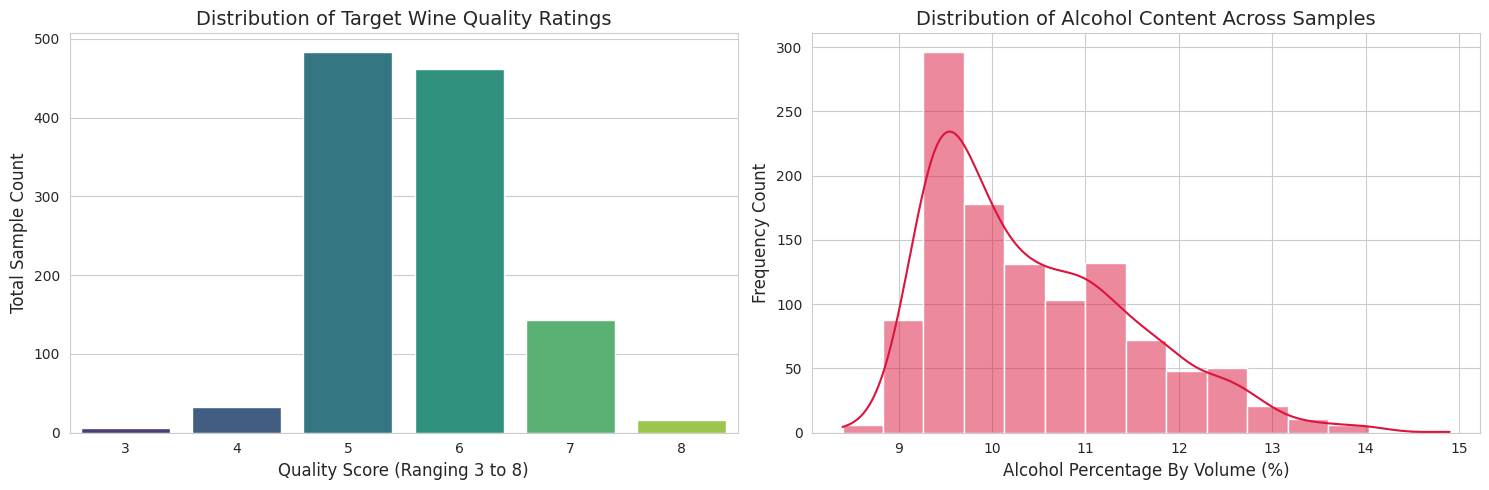

In [ ]:
# CODE CELL 6: Plotting Distributions of Target Variable and Alcohol Content
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Target distribution class assessment
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Target Wine Quality Ratings')
axes[0].set_xlabel('Quality Score (Ranging 3 to 8)')
axes[0].set_ylabel('Total Sample Count')

# Plot 2: Primary feature profile assessment
sns.histplot(data=df, x='alcohol', ax=axes[1], kde=True, color='crimson', bins=15)
axes[1].set_title('Distribution of Alcohol Content Across Samples')
axes[1].set_xlabel('Alcohol Percentage By Volume (%)')
axes[1].set_ylabel('Frequency Count')

plt.tight_layout()
plt.savefig('univariate_target_alcohol.png', dpi=150)
plt.show()

**8. Univariate Analysis (Part B - Acidity Outliers & Neutrality)**

*Univariate Analysis:*


*   What we are doing: Plotting a vertical boxplot for volatile_acidity to visualize extreme values, alongside a histogram showing the spread of ph across samples.
*   Why we do it: Boxplots help us easily spot data outliers that fall outside the typical interquartile range (IQR). This lets us see if extreme values are isolated instances or part of a broader pattern before moving into multi-variable comparisons

**Data Interpretation:** The volatile acidity boxplot shows a significant number of upper outliers stretching beyond 1.0 g/dm³. The pH histogram displays a very clean, symmetric bell curve centered at a neutral median value of roughly 3.3, indicating standard acidic parameters for wine preservation.

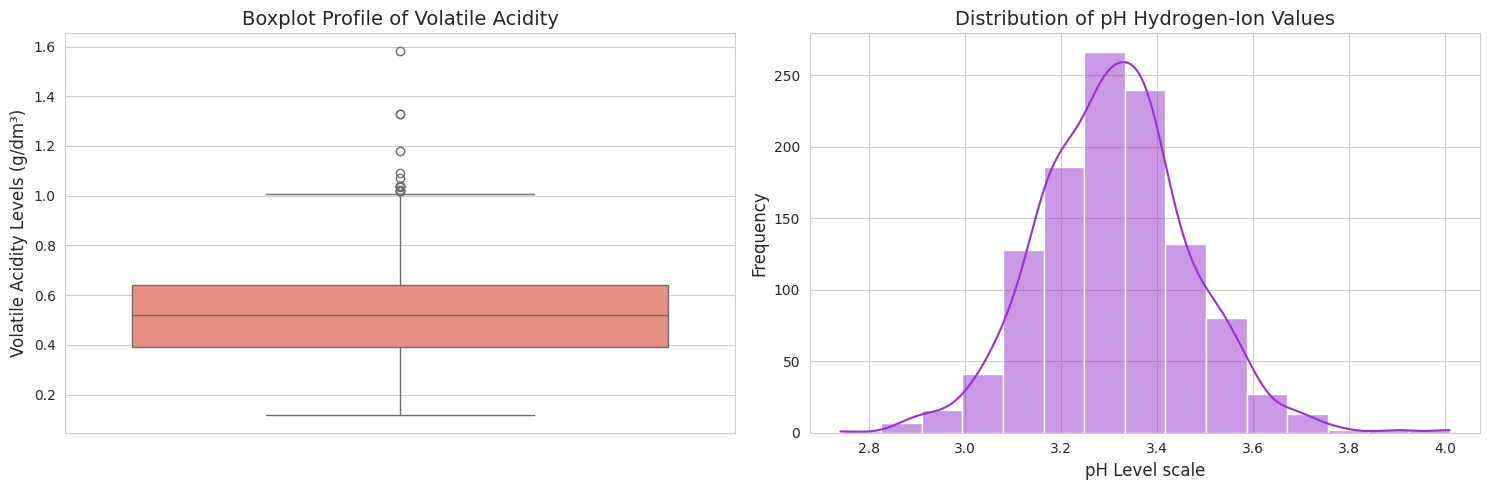

In [ ]:
# CODE CELL 7: Plotting Boxplot for Volatile Acidity and Histogram for pH
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 3: Boxplot targeting tracking anomalies
sns.boxplot(data=df, y='volatile_acidity', ax=axes[0], color='salmon')
axes[0].set_title('Boxplot Profile of Volatile Acidity')
axes[0].set_ylabel('Volatile Acidity Levels (g/dm³)')

# Plot 4: Continuous tracking assessment for pH
sns.histplot(data=df, x='ph', ax=axes[1], kde=True, color='darkorchid', bins=15)
axes[1].set_title('Distribution of pH Hydrogen-Ion Values')
axes[1].set_xlabel('pH Level scale')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('univariate_acidity_ph.png', dpi=150)
plt.show()

**9. Bivariate Analysis (Part A - Core Quality Interactions)**

*Bivariate Analysis*:

*   What we are doing: Creating side-by-side grouped boxplots (sns.boxplot) to see how the median and distribution of alcohol and volatile_acidity shift across different quality score groups.  
*   Why we do it: This allows us to directly evaluate the relationship between independent chemical properties and our target quality metric, revealing clear upward or downward trends as wine quality improves.

**Data Interpretation:** The boxplots reveal two clear, contrasting trends. As the target quality score increases from 5 to 8, the median alcohol level rises significantly. Conversely, volatile acidity drops sharply with higher ratings; top-tier wines (score 8) maintain low volatile acidity levels, safely avoiding the sour, vinegar-like profiles associated with lower scores.

/tmp/ipykernel_648/3236156058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y='alcohol', ax=axes[0], palette='coolwarm')
/tmp/ipykernel_648/3236156058.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y='volatile_acidity', ax=axes[1], palette='coolwarm_r')


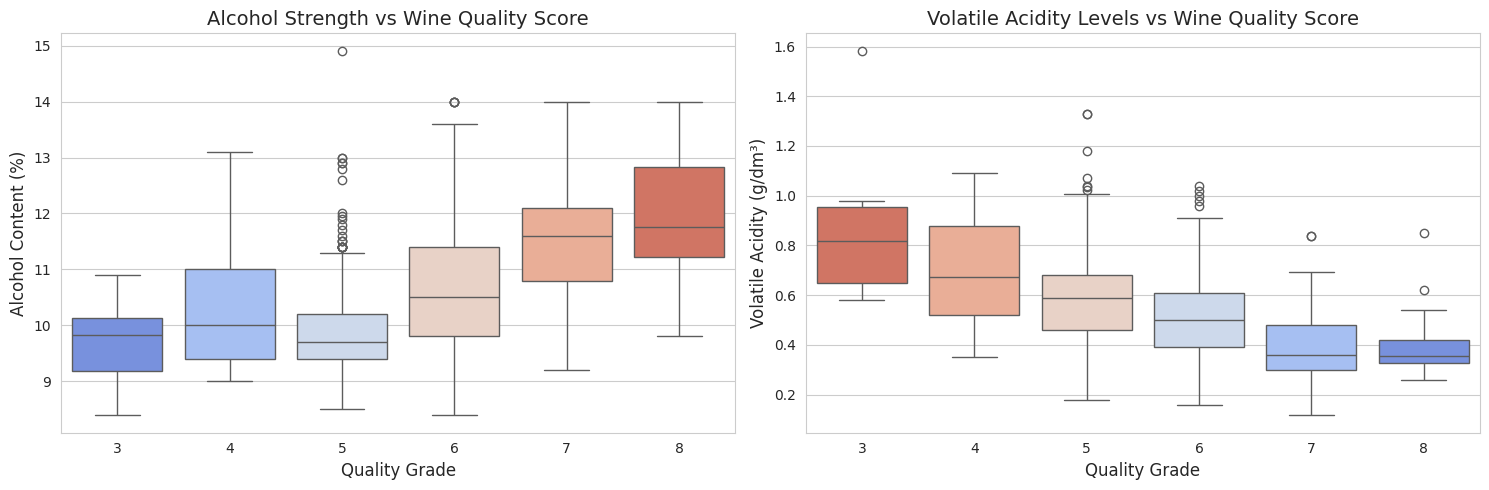

In [ ]:
# CODE CELL 8: Impact of Alcohol and Volatile Acidity on Final Quality
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Alcohol variations across quality tiers
sns.boxplot(data=df, x='quality', y='alcohol', ax=axes[0], palette='coolwarm')
axes[0].set_title('Alcohol Strength vs Wine Quality Score')
axes[0].set_xlabel('Quality Grade')
axes[0].set_ylabel('Alcohol Content (%)')

# Plot 2: Volatile Acidity variations across quality tiers
sns.boxplot(data=df, x='quality', y='volatile_acidity', ax=axes[1], palette='coolwarm_r')
axes[1].set_title('Volatile Acidity Levels vs Wine Quality Score')
axes[1].set_xlabel('Quality Grade')
axes[1].set_ylabel('Volatile Acidity (g/dm³)')

plt.tight_layout()
plt.savefig('bivariate_primary_drivers.png', dpi=150)
plt.show()

10. **Bivariate Analysis (Part B - Stabilizer Trends and Acid Balances)**

*Bivariate Analysis:*

*    What we are doing: Generating a bar plot to map mean sulphates against quality, alongside a continuous scatter plot to explore the relationship between citric_acid and volatile_acidity.
*   Why we do it: Bar plots isolate average baseline changes across groups, while multi-variable scatter plots let us see how two continuous chemical properties interact, with points color-coded by quality to reveal patterns across categories.

**Data Interpretation:** The bar chart shows that average sulphate levels increase steadily with wine quality, highlighting their role as a helpful stabilizing agent. The scatter plot reveals an inverse relationship: as citric acid content rises, volatile acidity drops. Higher-quality samples (represented by darker points) tend to cluster in the high-citric, low-volatile acidity zone at the bottom right.

/tmp/ipykernel_648/777841174.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='quality', y='sulphates', ax=axes[0], palette='plasma', ci=None)
/tmp/ipykernel_648/777841174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='quality', y='sulphates', ax=axes[0], palette='plasma', ci=None)


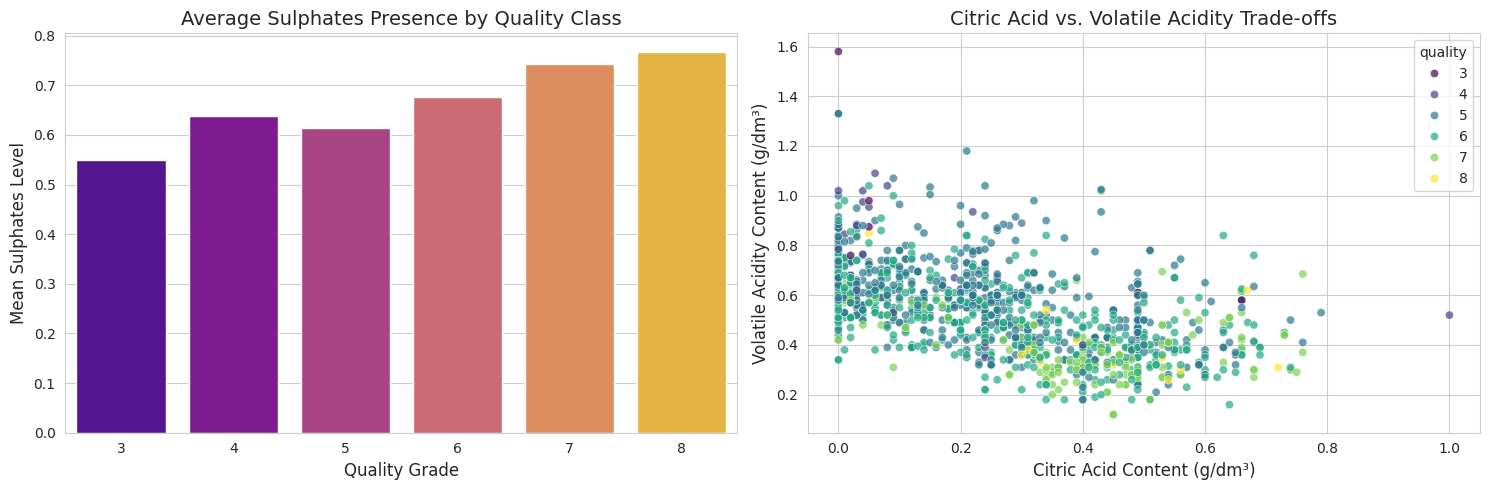

In [ ]:
# CODE CELL 9: Evaluating Sulphates Means and Multi-Acid Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 3: Average Sulphate distributions across categories
sns.barplot(data=df, x='quality', y='sulphates', ax=axes[0], palette='plasma', ci=None)
axes[0].set_title('Average Sulphates Presence by Quality Class')
axes[0].set_xlabel('Quality Grade')
axes[0].set_ylabel('Mean Sulphates Level')

# Plot 4: Continuous acid interaction scatter map
sns.scatterplot(data=df, x='citric_acid', y='volatile_acidity', hue='quality', ax=axes[1], palette='viridis', alpha=0.7)
axes[1].set_title('Citric Acid vs. Volatile Acidity Trade-offs')
axes[1].set_xlabel('Citric Acid Content (g/dm³)')
axes[1].set_ylabel('Volatile Acidity Content (g/dm³)')

plt.tight_layout()
plt.savefig('bivariate_stabilizer_acids.png', dpi=150)
plt.show()

**11. Multi-Variable Correlation Matrix**

*Correlation Heatmap Analysis*


*   What we are doing: Calculating a complete Pearson correlation matrix using df.corr() and mapping it with an annotated color heatmap via Seaborn.  
*   Why we do it: A correlation heatmap provides a comprehensive view of the entire dataset at a glance. It scales relationships from $-1.00$ (perfect inverse correlation) to $+1.00$ (perfect direct correlation), allowing us to instantly identify multicollinearity between predictors and determine which chemical properties matter most for predicting wine quality.

**Data Interpretation:**
The correlation matrix quantifies the key relationships in the dataset. alcohol stands out with the strongest positive correlation to quality ($+0.48$), followed by sulphates ($+0.26$) and citric_acid ($+0.24$). On the other hand, volatile_acidity shows a strong negative correlation ($-0.41$), confirming it as the primary chemical inhibitor of high wine quality ratings.

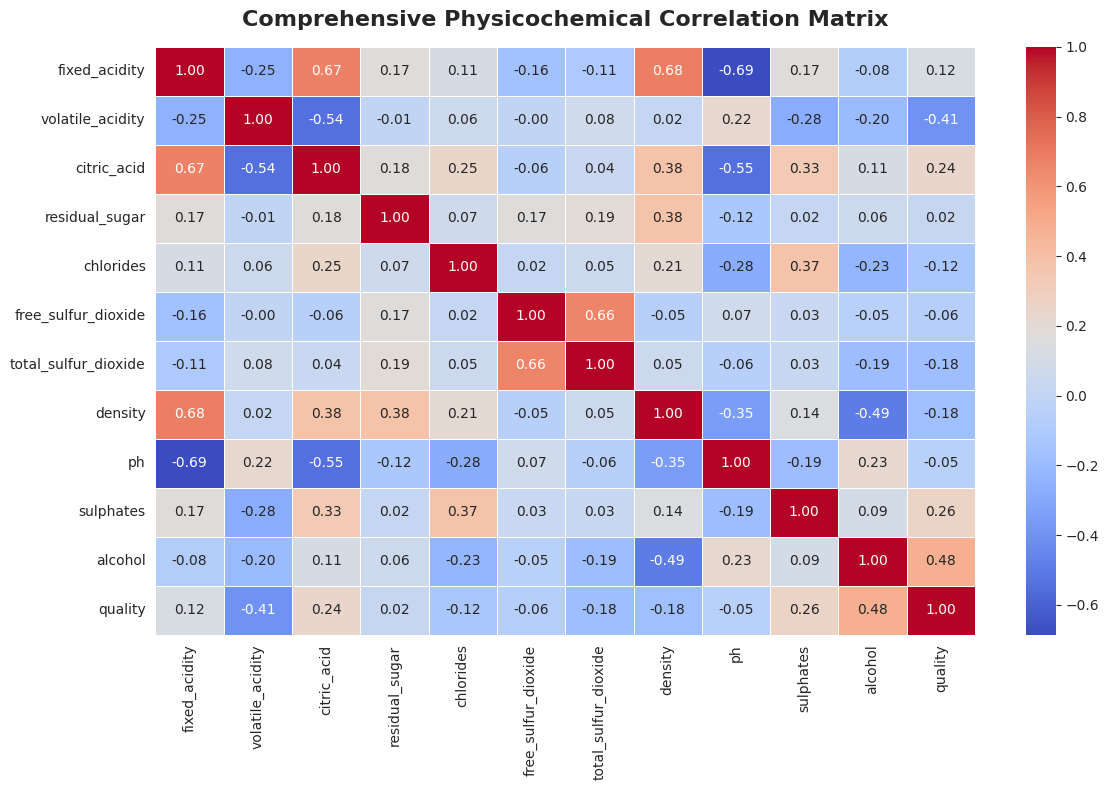

In [ ]:
# CODE CELL 10: Correlation Heatmap Matrix Generation
plt.figure(figsize=(12, 8))

# Compute mathematical linear coefficients
corr_matrix = df.corr()

# Draw visual heatmap matrix layout
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Comprehensive Physicochemical Correlation Matrix', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('correlation_matrix_heatmap.png', dpi=150)
plt.show()

**12. Insights & Conclusion**

Based on our comprehensive Exploratory Data Analysis (EDA) of the `WineQT.csv` dataset, here is a summary of the key strategic takeaways regarding the chemical profiles that determine wine quality:

*   **1. Alcohol Content is the Dominant Quality Driver ($+0.48$ Correlation):**
    Our analysis conclusively shows that alcohol percentage by volume has the strongest direct linear relationship with the wine's final rating. Premium-grade wines (rated 7 and 8) exhibit a noticeably higher median alcohol concentration (exceeding 11.5%), whereas lower-rated samples are tightly grouped around 9.5% to 10.0%.

*   **2. Volatile Acidity Acts as the Primary Quality Inhibitor ($-0.41$ Correlation):**
    High levels of volatile acidity heavily degrade the quality perception of the wine. Chemically, excess volatile acidity introduces an unappealing, sour, vinegar-like taste. The data proves that high-quality wines are carefully produced to keep these levels low—typically below 0.40 $\text{g/dm}^3$.

*   **3. The Crucial Preservation Role of Sulphates ($+0.26$ Correlation):**
    Average sulphate presence rises steadily alongside quality improvements. Sulphates act as essential antimicrobial and antioxidant stabilizing agents during the fermentation process. Higher sulphate management helps preserve fresh flavors and protects the wine from early deterioration.

*   **4. Acidity Trade-offs and Body Density ($+0.68$ Correlation):**
    The scatter and correlation plots reveal that superior wines maintain a careful structural balance: they favor fresh, crisp **citric acid** over sour **volatile acidity**. Furthermore, a strong direct relationship between fixed acidity and density indicates that the overall physical body and mouthfeel of the wine are fundamentally shaped by its underlying acid profile.

*   **5. Target Class Imbalance as a Machine Learning Constraint:**
    From a structural data perspective, the dataset's target variable (`quality`) is heavily centered on mediocre ratings (scores 5 and 6), while extreme scores (3 and 8) are exceptionally rare. If we use this data to train a predictive Machine Learning model in future labs, handling this class imbalance will be necessary to prevent bias toward middle-tier ratings.